# Consigna

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [233]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''
        noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Genera ruido gaussiano con varianza var.

        Nota: El ruido blanco se define como normal o gaussiano, con media 0 y con una varianza igual a la potencia de ruido
        (Extraido de apuntes de ASYS de procesos estocásticos, "ruido blanco")
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=var, size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))


# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

## Funcion

Funciones definidas para este ejercicio

In [234]:
def mi_adc(xx, Vfs, bits=4):
    '''
    Cuantizador que simula el comportamiento de un ADC
    xx: Señal a convertir
    Vfs: ADC [0, Vfs]
    bits: cantidad de Bits.
    ''' 
    q = Vfs/(2**bits) 
    xd = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xd, vmin, vmax, out=xd)
    #xd[xd > vmax] = vmax
    #xd[xd < vmin] = vmin
    return xd

def autocorrelate(xx):
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr
    

## Prueba 1:

Se realiza una prueba con una señal senoidal normalizada a 1W, pasada por un ADC.

In [235]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

VFS = 4
bits = 4

##### Funciones
xx, t = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
xq = mi_adc(xx, VFS, bits)
error = xx - xq
autocorr_error = autocorrelate(error)


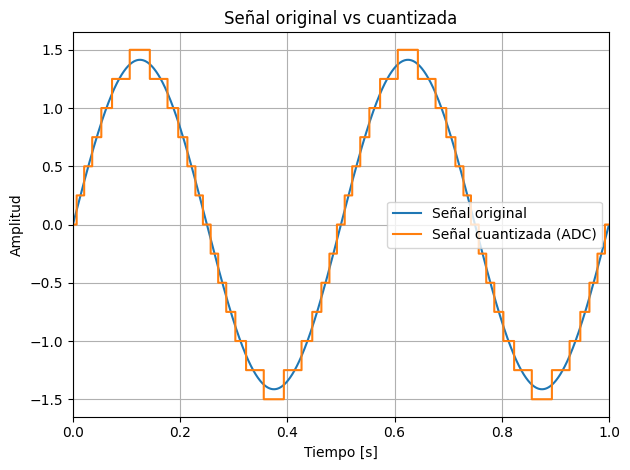

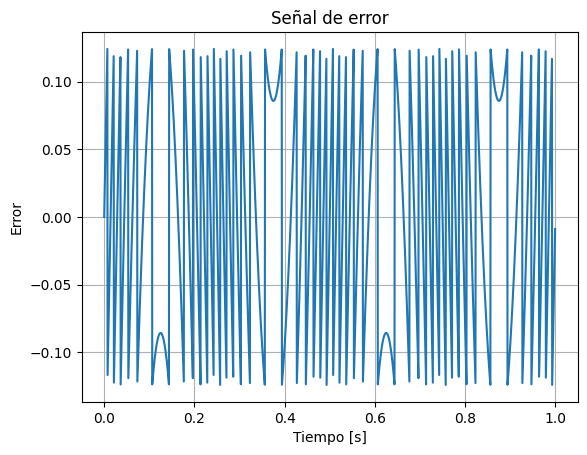

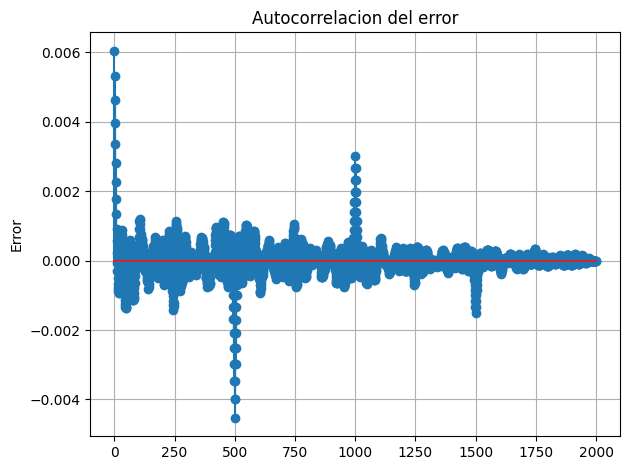

Varianza: 0.00604
Potencia de autocorrelacion: 0.00604
Cálculo matemático Señal Uniforme (q^2/12): 0.00521


In [236]:
##### Gráficos ADC
x_max = 2/freq

plt.figure()
plt.plot(t, xx, label="Señal original")
plt.step(t, xq, label="Señal cuantizada (ADC)")
plt.xlim([0, x_max])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


##### Gráficos error ADC
plt.figure()
plt.plot(t, error)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()

plt.show()

##### Autocrrelación de Error
plt.figure()
plt.stem(autocorr_error)
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()
plt.tight_layout()
plt.show()

##### Cálculos Potencia de señal de error
print(f"Varianza: {np.var(error, axis=0)[0]:.3g}")
print(f"Potencia de autocorrelacion: {autocorr_error[0][0]:.3g}")
q = VFS/2**bits
print(f"Cálculo matemático Señal Uniforme (q^2/12): {q**2/12:.3g}")


## Prueba 2: 

Senoidal con ruido
Se analizan ahora los efectos de la densidad espectral de potencia (PSD).

Nota: La PSD, por definición, se puede calcular como la transformada de fourier de la autocorrelación. Esta definición se utilizará para obtener la PSD de un proceso estocástico (Ruido).


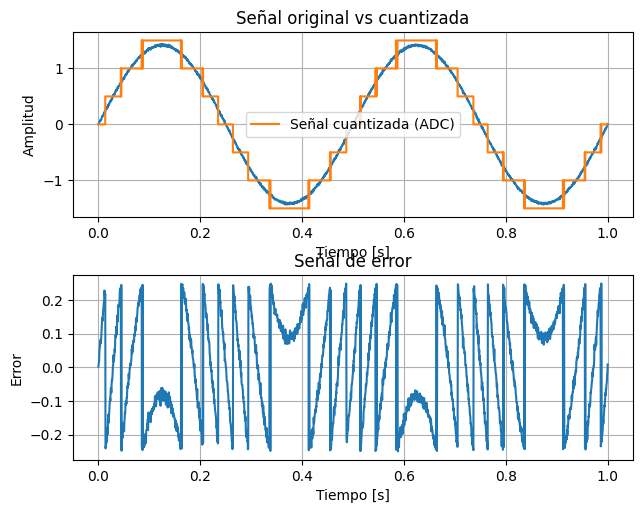

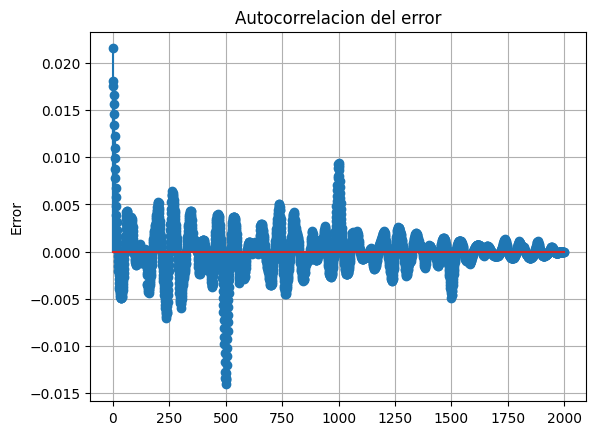

Varianza: 0.0215
Potencia de Autocorrelacion: 0.0215
Cálculo Matemático Señal Uniforme (q^2/12): 0.0208


In [237]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

VFS = 4 
bits = 3

##### Funciones
xx, t = mi_sen_ruidosa(vmax, ff=freq, ph=ph, nn=N, fs=fs, snr=20)
xq = mi_adc(xx, VFS, bits)
ff = np.concatenate((np.arange(0, fs/2, delta_f), np.arange(-fs/2, 0, delta_f)))


error = xx - xq
autocorr_error = autocorrelate(error)
psd_error_q = np.fft.fft(autocorr_error, axis=0)/autocorr_error.size
abs_psd_error = np.abs(psd_error_q)

xx_fft = np.fft.fft(xx, axis=0)/xx.size
abs_xx_fft = np.abs(xx_fft)

xq_fft = np.fft.fft(xq, axis=0)/xq.size
abs_xq_fft = np.abs(xq_fft)


##### Gráficos
plt.figure()
plt.subplot(2,1,1)
plt.plot(t, xx)
plt.step(t, xq, label="Señal cuantizada (ADC)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.tight_layout()
plt.grid()

# Señal de Error #####
plt.subplot(2,1,2)
plt.plot(t, error)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()
plt.show()


# Señal de Error #####
plt.figure()
plt.stem((autocorr_error))
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()
plt.show()

print(f"Varianza: {np.var(error, axis=0)[0]:.3g}")
print(f"Potencia de Autocorrelacion: {autocorr_error[0][0]:.3g}")
q = VFS/2**bits
print(f"Cálculo Matemático Señal Uniforme (q^2/12): {q**2/12:.3g}")


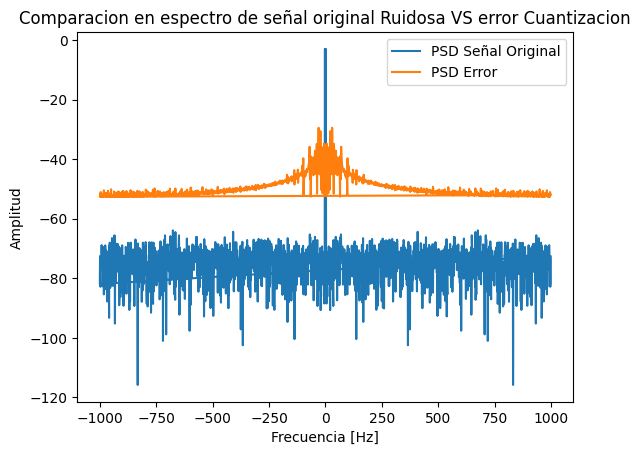

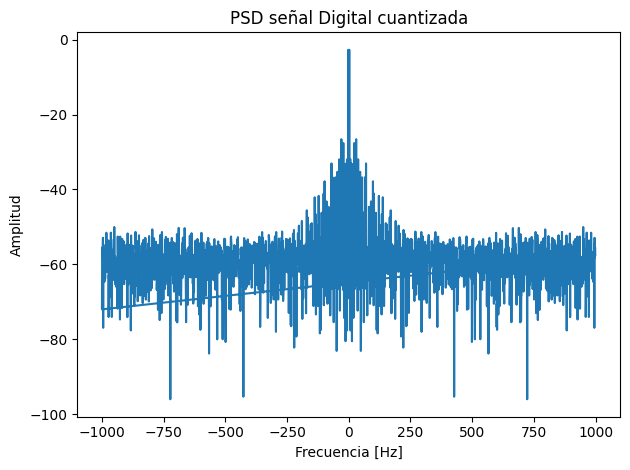

In [238]:


plt.figure()
plt.plot(ff, 20*np.log10(abs_xx_fft), label='PSD Señal Original')
plt.plot(ff, 10*np.log10(abs_psd_error), label='PSD Error')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Comparacion en espectro de señal original Ruidosa VS error Cuantizacion")
plt.legend()
plt.show()

plt.figure()
plt.plot(ff, 20*np.log10(np.maximum(abs_xq_fft, 1e-12)))       # 20, es señal de tension
plt.title("PSD señal Digital cuantizada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()


Cambiando el número de bits y el snr de la señal senoidal se pueden modificar los pisos de ruido correspondientes.
Como el ruido de cuantización es independiente del ruido de la señal, sus PSD no se suman y el piso de ruido resultante será el peor de ambos.
Si elijo muchos bits, llego a un límite de ruido impuesto por la señal de entrada.
Si elijo pocos bits, el piso de ruido se deberá por completo a la cuantización. 

Una señal real se "aparea" con el ADC cuando el número de bits genera un piso de ruido igual al de la señal de entrada. Se logra el mínimo ruido posible.
